# Visión por Computadora II - Trabajo Final

## Integrantes

- Acevedo Zain, Gaspar (acevedo.zain.gaspar@gmail.com)
- Lauro, Rodrigo (ing.rodrigo.lauro@gmail.com)
- Rodrigues da Cruz, Nicolás (Nicolasrdc151@gmail.com)

## Descripción del problema

- Tipo de problema: Clasificación
- Descripción: Detección de nódulos pulmonares en tomografías de tórax.
- Detalles: Desarrollar un modelo de aprendizaje profundo que identifique la presencia de nódulos pulmonares en imágenes de tomografía computarizada (CT) de tórax.​
- Dataset: [Chest CT-Scan images Dataset](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

## Imports

In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 27.0 MB/s eta 0:00:00


In [2]:
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

import torch
import cv2

import numpy as np
import pandas as pd

import os
from zipfile import ZipFile
from typing import Tuple
import math
import random

import matplotlib.pyplot as plt
from collections import Counter

from sklearn.decomposition import PCA

In [3]:
from torchvision.models import resnet18, ResNet18_Weights
import torchsummary
import torchmetrics
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Descarga del dataset

In [4]:
!curl -L -o "/content/dataset.zip" "https://www.kaggle.com/api/v1/datasets/download/mohamedhanyyy/chest-ctscan-images"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  118M  100  118M    0     0  88.7M      0  0:00:01  0:00:01 --:--:--  181M


In [5]:
zip_file = "/content/dataset.zip"
dataset_unzip_folder = "/content/."
dataset_folder = "/content/Data"
DATASET_TRAIN = os.path.join(dataset_folder, "train")
DATASET_TEST = os.path.join(dataset_folder, "test")
DATASET_VALID = os.path.join(dataset_folder, "valid")

In [6]:
# Descomprimo si NO existe la carpeta /content/dataset_emociones
if not os.path.isdir(dataset_folder):
  with ZipFile(zip_file, 'r') as zip_object:
    zip_object.extractall(path=dataset_unzip_folder)

## Data Augmentation

En esta sección se aplica el mismo `data augmentation` que se definió en la sección `EDA - Definición de Transformaciones y Data Augmentation` de la notebook [trabajo-final.ipynb](https://github.com/gasper-az/vision-computadora-II-trabajo-final/blob/main/trabajo-final.ipynb).

Comenzamos obteniendo las media y desvío estándar del dataset de `train`, a fin de utilizarlas para normalizar las imágenes:

In [7]:
basic_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
])

train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=basic_transform)

train_loader_for_stats = DataLoader(train_data, batch_size=64, shuffle=False)

def get_mean_std(loader):
    """
    Calcula la media y la desviación estándar por canal (RGB) de un
    conjunto de datos cargado por un DataLoader.
    """
    channels_sum, channels_sqrd_sum, num_batches = 0, 0, 0

    print("Calculando media y std del dataset de train...")
    for data, _ in loader:
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_sqrd_sum += torch.mean(data**2, dim=[0, 2, 3])
        num_batches += 1

    mean = channels_sum / num_batches
    std = (channels_sqrd_sum / num_batches - mean**2)**0.5
    return mean, std

dataset_mean, dataset_std = get_mean_std(train_loader_for_stats)

Calculando media y std del dataset de train...


Se definen las mismas transformaciones que en la sección `Definición de Transformaciones y Data Augmentation` de la notebook [trabajo-final.ipynb](https://github.com/gasper-az/vision-computadora-II-trabajo-final/blob/main/trabajo-final.ipynb).

In [8]:
val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(5, 9), sigma=(0.1, 5.0))
    ], p=0.5),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean, std=dataset_std)
])

## Función para train-test loop

A continuación, se define el *loop* principal de entrenamiento. Este proceso iterará sobre el número de `EPOCHS` definido.

En cada época, se realizan dos fases:

1.  **Fase de Entrenamiento (`model.train()`):**
    * Se itera sobre el `train_loader`.
    * Se realiza el *forward pass* (propagación hacia adelante).
    * Se calcula la pérdida (***Loss***) comparando las predicciones con las etiquetas reales (usando `criterion`).
    * Se realiza el *backward pass* (retropropagación) y se actualizan los pesos del modelo (`optimizer.step()`).
    * Se acumulan la *loss* y las métricas de esta fase.

2.  **Fase de Validación (`model.eval()`):**
    * Se desactiva el cálculo de gradientes (`with torch.no_grad()`) para ahorrar cómputo, ya que en esta fase no se aprende.
    * Se itera sobre el `validation_loader`.
    * Se evalúa el rendimiento del modelo sobre datos "no vistos" (el conjunto de validación).
    * Se acumulan la *loss* y las métricas de validación.

Además, se implementará un mecanismo de **Early Stopping**. Este monitoreará la pérdida de validación (`val_loss`) y detendrá el entrenamiento si esta no mejora después de un número determinado de épocas (`patience`), evitando así el *overfitting* y ahorrando tiempo de cómputo.

Se almacenará el historial de *loss* y métricas de ambas fases en cada época para su posterior visualización.

In [12]:
def train_eval_loop(model: any, optimizer, criterion, metric,
                    data: dict, epochs: int = 100, tb_writer: dict = None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    train_loader = data["train"]
    valid_loader = data["valid"]

    if tb_writer:
        train_writer = tb_writer["train"]
        valid_writer = tb_writer["valid"]

        train_writer.add_graph(model, torch.zeros((1, data["image_channels"],
                                                     data["image_width"],
                                                     data["image_height"])))
        valid_writer.add_graph(model, torch.zeros((1, data["image_channels"],
                                                     data["image_width"],
                                                     data["image_height"])))
    model.to(device)
    metric.to(device)

    train_loss = []
    train_metric = []
    valid_loss = []
    valid_metric = []

    patience = 5  # Número de épocas de paciencia antes de detenerse
    best_val_loss = float('inf') # Se busca minimizar la loss de validación
    epochs_no_improve = 0
    # ----------------------------------------

    # (La variable 'history' se crea al final, con los resultados)

    # Corregido: Usar 'epochs' (argumento) en lugar de 'EPOCHS' (indefinido)
    print(f"Iniciando entrenamiento por {epochs} épocas...")
    print(f"Early Stopping activado con paciencia de {patience} épocas.")

    for epoch in range(epochs):

        ####################  TRAIN  ####################
        model.train()

        epoch_train_loss = 0.0
        epoch_train_metric = 0.0

        for train_data, train_target in train_loader:

            train_data = train_data.to(device)
            train_target = train_target.to(device)

            optimizer.zero_grad()
            output = model(train_data.float())
            loss = criterion(output, train_target)
            epoch_train_loss += loss.item()
            loss.backward()
            optimizer.step()

            epoch_train_metric += metric(output, train_target).item()

        epoch_train_loss = epoch_train_loss / len(train_loader)
        epoch_train_metric = epoch_train_metric / len(train_loader)
        train_loss.append(epoch_train_loss)
        train_metric.append(epoch_train_metric)

        ####################  EVAL  ####################
        model.eval()

        epoch_valid_loss = 0.0
        epoch_valid_metric = 0.0

        all_preds = torch.tensor([]).to(device)
        all_labels = torch.tensor([]).to(device)

        # Desactivamos gradientes para la validación
        with torch.no_grad():
            for valid_data, valid_target in valid_loader:
                valid_data = valid_data.to(device)
                valid_target = valid_target.to(device)

                output = model(valid_data.float())
                epoch_valid_loss += criterion(output, valid_target).item()
                epoch_valid_metric += metric(output, valid_target).item()

                all_preds = torch.cat((all_preds, output))
                all_labels = torch.cat((all_labels, valid_target))

        epoch_valid_loss = epoch_valid_loss / len(valid_loader)
        epoch_valid_metric = epoch_valid_metric / len(valid_loader)
        valid_loss.append(epoch_valid_loss)
        valid_metric.append(epoch_valid_metric)

        print("Epoch: {}/{} - Train loss {:.6f} - Train Metric {:.6f} - Valid Loss {:.6f} - Valid Metric {:.6f}".format(
        epoch+1, epochs, epoch_train_loss, epoch_train_metric, epoch_valid_loss, epoch_valid_metric))

        if tb_writer:
            train_writer.add_scalar("loss", epoch_train_loss, epoch)
            valid_writer.add_scalar("loss", epoch_valid_loss, epoch)
            train_writer.add_scalar("metric", epoch_train_metric, epoch)
            valid_writer.add_scalar("metric", epoch_valid_metric, epoch)
            train_writer.flush()
            valid_writer.flush()

        # --- Lógica de Early Stopping ---
        if epoch_valid_loss < best_val_loss:
            print(f"    Mejora en Val Loss: ({best_val_loss:.4f} --> {epoch_valid_loss:.4f}). Guardando modelo...")
            best_val_loss = epoch_valid_loss
            epochs_no_improve = 0
            # Opcional: guardar el mejor modelo
            # torch.save(model.state_dict(), 'best_model.pth')
        else:
            epochs_no_improve += 1
            print(f"    No hay mejora en Val Loss por {epochs_no_improve} épocas.")

        if epochs_no_improve == patience:
            print(f"\n¡EARLY STOPPING! No hubo mejora en {patience} épocas. Deteniendo entrenamiento en epoch {epoch+1}.")
            break  # Se rompe el loop 'for epoch...'
        # ----------------------------------

    # Se arma el diccionario 'history' al final, con los resultados
    history = {}
    history["train_loss"] = train_loss
    history["train_metric"] = train_metric
    history["valid_loss"] = valid_loss
    history["valid_metric"] = valid_metric
    history["labels_last_epoch"] = all_labels
    history["pred_last_epoch"] = all_preds

    return history

## Constants

In [13]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
OUTPUTS = 4
CANT_CLASES = 4

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## ResNet 152

### Definición de datasets para el modelo

In [34]:
train_data = datasets.ImageFolder(root=DATASET_TRAIN, transform=train_transform)
validation_data = datasets.ImageFolder(root=DATASET_VALID, transform=val_test_transform)
test_data = datasets.ImageFolder(root=DATASET_TEST, transform=val_test_transform)

Se crean a continuación los dataloaders de `train`, `test` y `validation`, utilizando un ***Batch Size*** de $32$. El único data loader con `shuffle = True` es el de `train`.

In [35]:
BATCH_SIZE = 32

In [36]:
train_loader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
validation_loader = DataLoader(dataset=validation_data, batch_size=BATCH_SIZE, shuffle=False)

### Definición del modelo

In [14]:
from torchvision.models import resnet152, ResNet152_Weights

# Se cargan los pesos 'IMAGENET1K_V1'. Estos son los pesos finales y
# optimizados que la red aprendió tras ser entrenada en el dataset.
weights = ResNet152_Weights.IMAGENET1K_V1

# Se inicializa el modelo ResNet152 con los pesos pre-entrenados.
resnet152_model = resnet152(weights=weights)

Downloading: "https://download.pytorch.org/models/resnet152-394f9c45.pth" to /root/.cache/torch/hub/checkpoints/resnet152-394f9c45.pth


100%|██████████| 230M/230M [00:01<00:00, 201MB/s]


In [17]:
transforms = weights.transforms()
transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [21]:
resnet152_model.to(device)

torchsummary.summary(resnet152_model, input_size=(IMG_CHANNELS, IMG_HEIGHT, IMG_WIDTH))
resnet152_model.modules

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

<bound method Module.modules of ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): Bottleneck(
      (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (2): Bottleneck(
      (conv1): Conv2d(256, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
  )
  (layer2): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(128, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(256, 512, kernel_size=(1, 1), stride=(2, 2), bias=False)
        (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (1): Bottleneck(
      (conv1): Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(128, 512, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (2): Bottleneck(
      (conv1): Conv2d(512, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(128, 128, kernel_size

In [24]:
for param in resnet152_model.parameters():
    param.requires_grad = False

last_layer_in_features = resnet152_model.fc.in_features
resnet152_model.fc = torch.nn.Linear(in_features=last_layer_in_features, out_features=OUTPUTS)

In [25]:
last_layer_in_features

2048

### Entrenamiento

In [26]:
criterion = torch.nn.CrossEntropyLoss()

In [27]:
metric = torchmetrics.Recall(task='multiclass', num_classes=CANT_CLASES)

In [29]:
LEARNING_RATE = 1e-4

In [30]:
optimizer = torch.optim.Adam(resnet152_model.fc.parameters(), lr=LEARNING_RATE)

In [31]:
data = {"train": train_loader, "valid": test_loader, "image_width": IMG_WIDTH, "image_height": IMG_HEIGHT}

In [32]:
EPOCHS = 100

In [33]:
history_resnet152 = train_eval_loop(model=resnet152_model, optimizer=optimizer,
                                    criterion=criterion, metric=metric,
                                    data=data, epochs=EPOCHS, tb_writer=None)

Iniciando entrenamiento por 100 épocas...
Early Stopping activado con paciencia de 5 épocas.
Epoch: 1/100 - Train loss 1.358569 - Train Metric 0.299688 - Valid Loss 1.309387 - Valid Metric 0.374653
    Mejora en Val Loss: (inf --> 1.3094). Guardando modelo...
Epoch: 2/100 - Train loss 1.290573 - Train Metric 0.425625 - Valid Loss 1.328793 - Valid Metric 0.398843
    No hay mejora en Val Loss por 1 épocas.
Epoch: 3/100 - Train loss 1.231017 - Train Metric 0.523125 - Valid Loss 1.263949 - Valid Metric 0.399421
    Mejora en Val Loss: (1.3094 --> 1.2639). Guardando modelo...
Epoch: 4/100 - Train loss 1.172064 - Train Metric 0.558750 - Valid Loss 1.226017 - Valid Metric 0.466435
    Mejora en Val Loss: (1.2639 --> 1.2260). Guardando modelo...
Epoch: 5/100 - Train loss 1.138137 - Train Metric 0.573750 - Valid Loss 1.190925 - Valid Metric 0.472685
    Mejora en Val Loss: (1.2260 --> 1.1909). Guardando modelo...
Epoch: 6/100 - Train loss 1.097919 - Train Metric 0.588438 - Valid Loss 1.163924 

### Gráficos

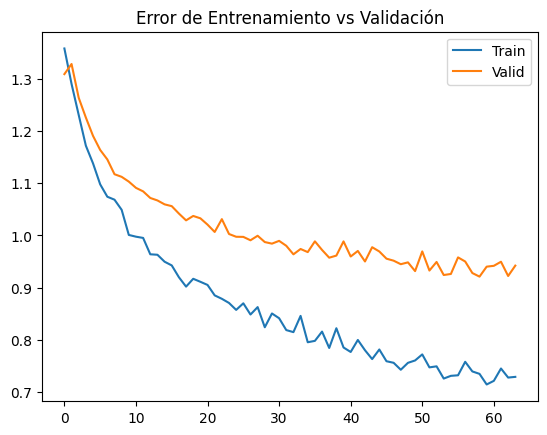

In [37]:
plt.plot(history_resnet152["train_loss"])
plt.plot(history_resnet152["valid_loss"])
plt.title("Error de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

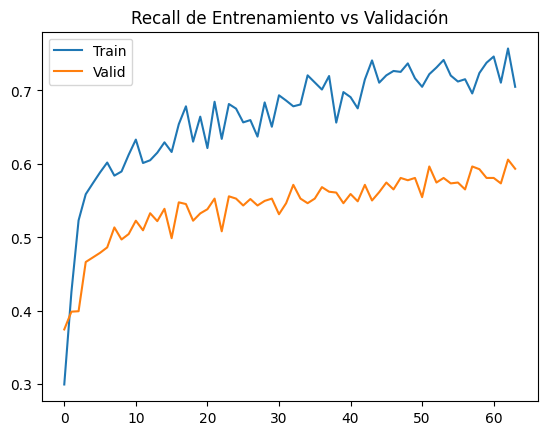

In [38]:
plt.plot(history_resnet152["train_metric"])
plt.plot(history_resnet152["valid_metric"])
plt.title("Recall de Entrenamiento vs Validación")
plt.legend(['Train', 'Valid'])

### Métricas

In [48]:
print(f"Métrica final en train: {history_resnet152["train_metric"][-1]}")

Métrica final en train: 0.7050000011920929


In [47]:
print(f"Métrica final en validation: {history_resnet152["valid_metric"][-1]}")

Métrica final en validation: 0.5934027791023254


### Classification Report

In [39]:
report = classification_report(y_true=history_resnet152["labels_last_epoch"].cpu(), y_pred=history_resnet152["pred_last_epoch"].argmax(dim=1).cpu(), target_names=train_data.classes)

In [40]:
print(report)

                                                  precision    recall  f1-score   support

      adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib       0.67      0.38      0.49       120
   large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa       0.73      0.22      0.33        51
                                          normal       0.96      0.98      0.97        54
squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa       0.43      0.84      0.57        90

                                        accuracy                           0.59       315
                                       macro avg       0.70      0.61      0.59       315
                                    weighted avg       0.66      0.59      0.57       315



### Matriz de confusión

In [42]:
cm = confusion_matrix(history_resnet152["labels_last_epoch"].cpu(), history_resnet152["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()))

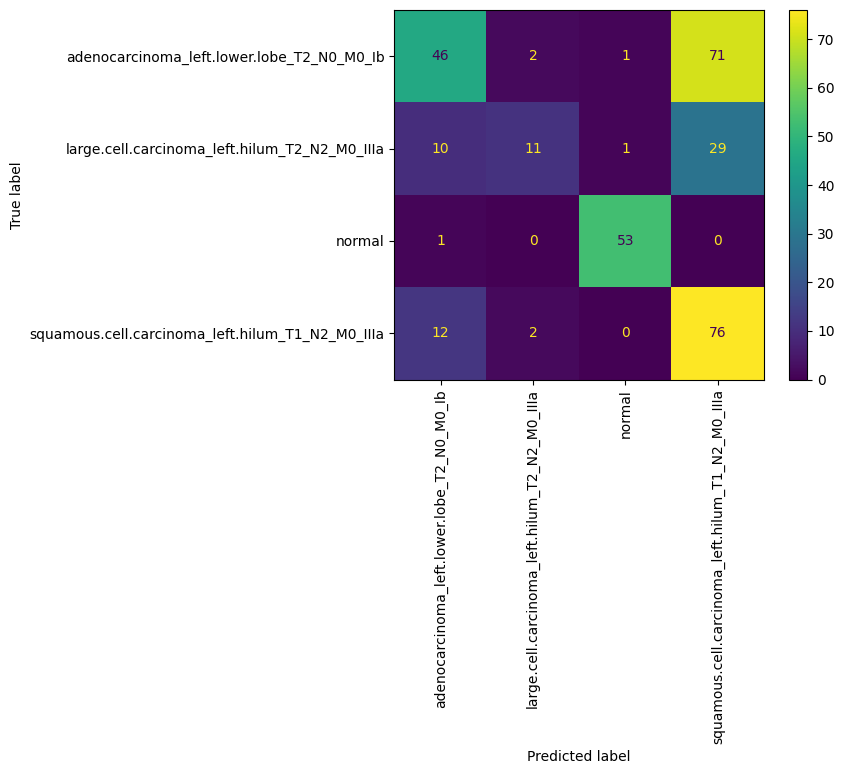

In [43]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=train_data.classes)
disp.plot()
disp.ax_.tick_params(axis='x', rotation=90)
plt.show()

### Matriz de confusión normalizada por fila

In [44]:
cm_normalized_by_row = confusion_matrix(history_resnet152["labels_last_epoch"].cpu(), history_resnet152["pred_last_epoch"].argmax(dim=1).cpu(), labels=list(train_data.class_to_idx.values()), normalize='true')

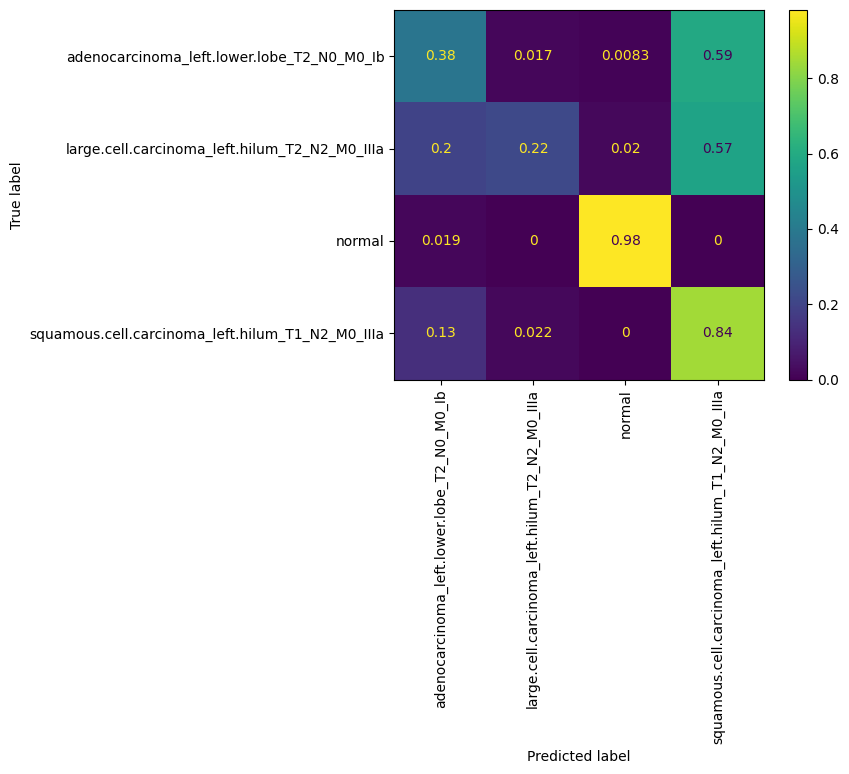

In [45]:
disp_normalized = ConfusionMatrixDisplay(confusion_matrix=cm_normalized_by_row, display_labels=train_data.classes)
disp_normalized.plot()
disp_normalized.ax_.tick_params(axis='x', rotation=90)
plt.show()